# EDA

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

df = pd.read_csv(Path("../data/raw/sleep_health.csv"))
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## Types and missing values

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


`Blood Pressure` comes in as text. `Sleep Disorder` is the only column with nulls.

In [3]:
df["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

The nulls in `Sleep Disorder` mean no disorder, so it is a category.

## Duplicates

In [4]:
without_id = df.drop(columns=["Person ID"])
print("rows:", len(df))
print("unique rows ignoring Person ID:", len(without_id.drop_duplicates()))

rows: 374
unique rows ignoring Person ID: 132


132 distinct rows out of 374 once `Person ID` is ignored.

## Blood pressure

In [5]:
bp = df["Blood Pressure"].str.split("/", expand=True).astype(int)
df["Systolic"] = bp[0]
df["Diastolic"] = bp[1]
df[["Blood Pressure", "Systolic", "Diastolic"]].head()

,Blood Pressure,Systolic,Diastolic
0,126/83,126,83
1,125/80,125,80
2,125/80,125,80
3,140/90,140,90
4,140/90,140,90


In [6]:
df[["Systolic", "Diastolic"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Systolic,374.0,128.553476,7.748118,115.0,125.0,130.0,135.0,142.0
Diastolic,374.0,84.649733,6.161611,75.0,80.0,85.0,90.0,95.0


Systolic goes from 115 to 142, diastolic from 75 to 95.

## Numeric features

In [7]:
numeric = df.select_dtypes("number").drop(columns=["Person ID"])
numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,374.0,42.184492,8.673133,27.0,35.25,43.0,50.0,59.0
Sleep Duration,374.0,7.132086,0.795657,5.8,6.40,7.2,7.8,8.5
Quality of Sleep,374.0,7.312834,1.196956,4.0,6.00,7.0,8.0,9.0
Physical Activity Level,374.0,59.171123,20.830804,30.0,45.00,60.0,75.0,90.0
Stress Level,374.0,5.385027,1.774526,3.0,4.00,5.0,7.0,8.0
Heart Rate,374.0,70.165775,4.135676,65.0,68.00,70.0,72.0,86.0
Daily Steps,374.0,6816.844920,1617.915679,3000.0,5600.00,7000.0,8000.0,10000.0
Systolic,374.0,128.553476,7.748118,115.0,125.00,130.0,135.0,142.0
Diastolic,374.0,84.649733,6.161611,75.0,80.00,85.0,90.0,95.0


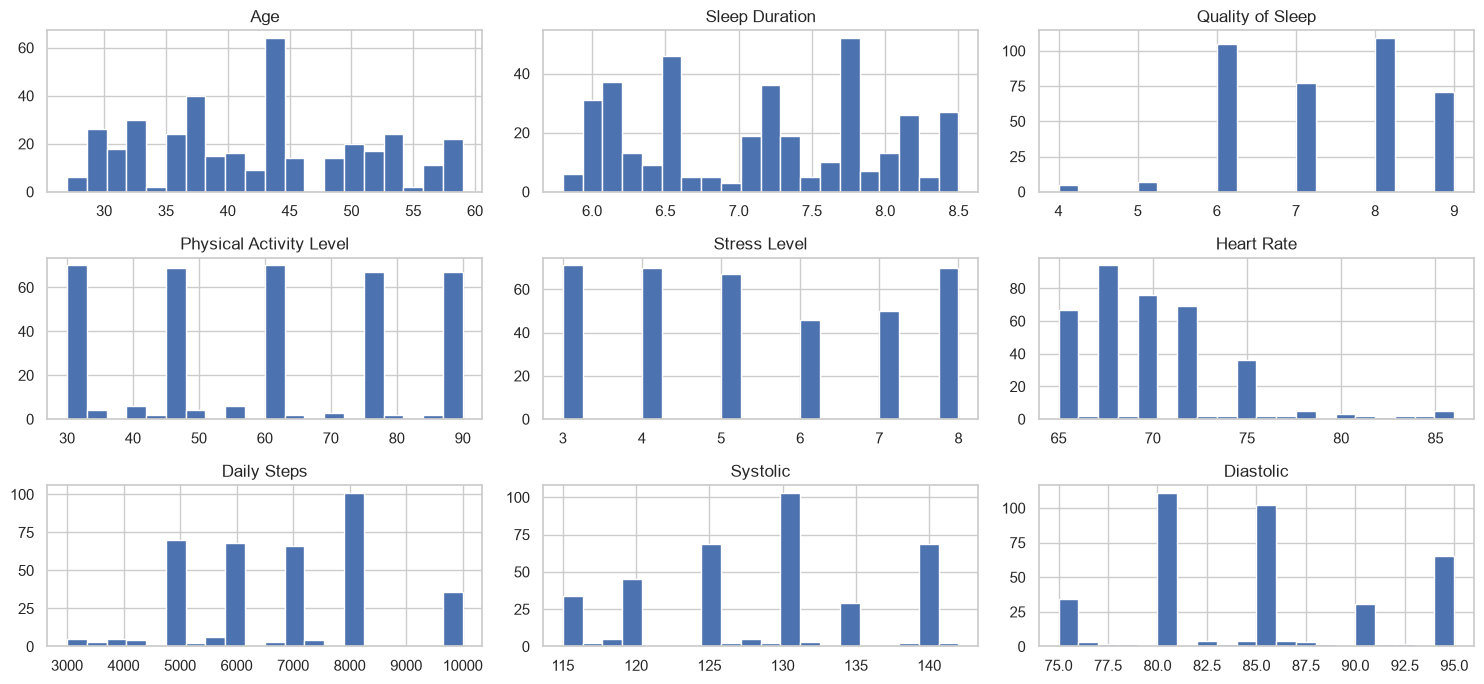

In [8]:
numeric.hist(figsize=(15, 7), bins=20)
plt.tight_layout()

## Correlations

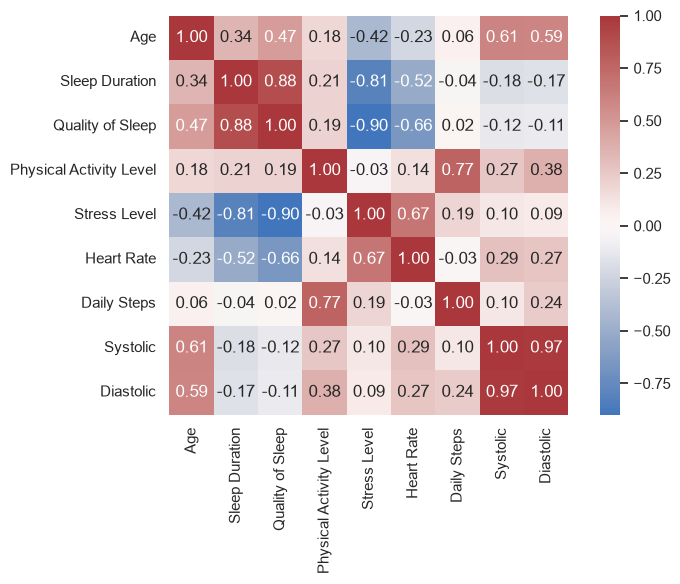

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.tight_layout()

Three groups of variables. Sleep duration, quality of sleep, stress and heart rate move together. Physical activity and daily steps move together (0.77). Systolic and diastolic pressure are almost the same number (0.97) and go with age (0.6). Between the groups the correlations are small.

## Categorical features

In [10]:
df["Gender"].value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

In [11]:
df["BMI Category"].value_counts()

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

In [12]:
df["Occupation"].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

`BMI Category` has both `Normal` and `Normal Weight`. `Occupation` goes from 73 nurses down to a single manager, with four occupations under 5 people.

## BMI category against sleep disorder

In [13]:
pd.crosstab(df["BMI Category"], df["Sleep Disorder"].fillna("None"))

Sleep Disorder,Insomnia,None,Sleep Apnea
BMI Category,,,
Normal,7,183,5
Normal Weight,2,17,2
Obese,4,0,6
Overweight,64,19,65


Almost all disorders sit in the `Overweight` group: 64 insomnia and 65 apnea against 19 with none. `Normal` has 183 out of 195 without a disorder.

## How coarse are the values

In [14]:
df.nunique().sort_values()

Gender                       2
Sleep Disorder               2
BMI Category                 4
Quality of Sleep             6
Stress Level                 6
Occupation                  11
Physical Activity Level     16
Diastolic                   17
Systolic                    18
Heart Rate                  19
Daily Steps                 20
Blood Pressure              25
Sleep Duration              27
Age                         31
Person ID                  374
dtype: int64

In [15]:
df["Daily Steps"].value_counts().sort_index()

Daily Steps
3000       3
3300       2
3500       3
3700       2
4000       3
4100       2
4200       2
4800       2
5000      68
5200       2
5500       4
5600       2
6000      68
6200       1
6800       3
7000      66
7300       2
7500       2
8000     101
10000     36
Name: count, dtype: int64

339 people out of 374 are on five round values (5000, 6000, 7000, 8000, 10000). The other 15 values have between 1 and 4 people each.

## Occupation against sleep and stress

In [16]:
common = df["Occupation"].value_counts()
common = common[common >= 30].index
(
    df[df["Occupation"].isin(common)]
    .groupby("Occupation")[["Sleep Duration", "Quality of Sleep", "Stress Level"]]
    .mean()
    .round(2)
    .sort_values("Stress Level")
)

,Sleep Duration,Quality of Sleep,Stress Level
Occupation,,,
Engineer,7.99,8.41,3.89
Teacher,6.69,6.98,4.53
Accountant,7.11,7.89,4.59
Lawyer,7.41,7.89,5.06
Nurse,7.06,7.37,5.55
Doctor,6.97,6.65,6.73
Salesperson,6.40,6.00,7.00


Mean stress goes from 3.9 for engineers to 7.0 for salespeople. Sleep duration and quality differ across occupations too, but not in the same order.

## Numeric features by sleep disorder

In [17]:
df.groupby(df["Sleep Disorder"].fillna("None"))[
    ["Sleep Duration", "Quality of Sleep", "Stress Level", "Heart Rate", "Systolic", "Age"]
].mean().round(2)

,Sleep Duration,Quality of Sleep,Stress Level,Heart Rate,Systolic,Age
Sleep Disorder,,,,,,
Insomnia,6.59,6.53,5.87,70.47,132.04,43.52
None,7.36,7.63,5.11,69.02,124.05,39.04
Sleep Apnea,7.03,7.21,5.67,73.09,137.77,49.71


The apnea group sleeps almost as long as the group with no disorder (7.03 vs 7.36 hours) and rates its sleep quality similarly (7.21 vs 7.63). The difference is in heart rate (73 vs 69), systolic pressure (138 vs 124) and age (50 vs 39). Insomnia, instead, shows up in sleep duration and quality.

## What I take from this

Three groups of variables that are mostly unrelated to each other: sleep duration, quality of sleep, stress and heart rate; physical activity and daily steps; blood pressure and age. Inside each group the columns are close to redundant.

Blood Pressure has to be split in two numbers, and Normal Weight belongs with Normal. Many values repeat: 242 rows are copies of another row, so clustering scores will look better than they would on real data. Sleep Disorder is not going to be a feature, it is the natural check for the clusters. Sleep apnea shows in heart rate, blood pressure and age more than in the reported sleep.